# Clasificador de rango etario 

### Modificación respecto al estudio anterior: `Disminución del número de categorías + balanceo por etnia y edad`

**Este balanceo se aplicó para eliminar el sesgo que puede generar la etnia, ya que el que el modelo puede asociar rasgos determinados de una etnia a un rango etario específico.**  

Clasificación multiclase en 5 clases a partir de fotos de rostros, en PyTorch y en TensorFlow/Keras.

Los segmentos de edad:

| Clase | Rango | Etiqueta |
|---|---|---|
| 0 | 0-18 | niños |
| 1 | 19-30 | jóvenes |
| 2 | 31-45 | adulto joven |
| 3 | 46-60 | adulto |
| 4 | 61+ | adulto mayor |


# Desarrollo

In [1]:
# --- Configuración general ---
import os
import re
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"     # carpeta única con todas las imágenes (sin subcarpetas por clase)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [2]:
# --- Definición de los segmentos etarios y utilidades ---
CLASS_NAMES = ["niños", "jóvenes", "adulto joven", "adulto", "adulto mayor"]

# Códigos de etnia de UTKFace (campo 3 del nombre de archivo).
# 'Others' (código 4) se EXCLUYE del entrenamiento: agrupa etnias muy distintas entre sí
# (incluye hispanos/latinos) y no aporta una categoría étnica consistente para el balanceo.
RACE_NAMES = {0: "White", 1: "Black", 2: "Asian", 3: "Indian"}

def age_to_segment(age: int) -> int:
    """Convierte una edad entera al índice de segmento (0-4) según los nuevos rangos."""
    if age <= 18:
        return 0  # niños
    elif age <= 30:
        return 1  # jóvenes
    elif age <= 45:
        return 2  # adulto joven
    elif age <= 60:
        return 3  # adulto
    else:
        return 4  # adulto mayor

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

def parse_race_from_filename(filename: str):
    """Extrae el código de etnia del nombre '[edad]_[genero]_[raza]_[fecha].jpg'.
    Devuelve None si no calza o si la etnia es 'Others' (excluida)."""
    parts = os.path.basename(filename).split("_")
    try:
        race = int(parts[2])
        return race if race in RACE_NAMES else None
    except (ValueError, IndexError):
        return None

In [3]:
# --- Construcción del dataframe desde la carpeta única UTKFace ---
# El segmento etario y la etnia se calculan parseando el NOMBRE DE ARCHIVO (no hay subcarpetas).
# La etnia 'Others' queda excluida (parse_race_from_filename la descarta).
# Balanceo doble: se cuenta cada combinación (segmento, etnia) y se usa el MÍNIMO GLOBAL entre
# todas las combinaciones como cap único -> mismo N° de imágenes por etnia en cada segmento.
all_fps = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
if len(all_fps) == 0:
    raise FileNotFoundError(
        f"No hay imágenes en '{DATA_DIR}'. Revisa que la carpeta UTKFace exista con los .jpg "
        "directamente adentro (ver celda de descarga del dataset)."
    )

records_by_bucket = {(s, r): [] for s in range(len(CLASS_NAMES)) for r in RACE_NAMES}
skipped = 0
for fp in all_fps:
    age = parse_age_from_filename(fp)
    race = parse_race_from_filename(fp)
    if age is None or race is None:
        skipped += 1
        continue
    records_by_bucket[(age_to_segment(age), race)].append(fp)

print(f"Imágenes totales encontradas: {len(all_fps)}  |  Descartadas (nombre inválido o etnia 'Others'/desconocida): {skipped}")
print("Disponibles por (segmento, etnia) antes de balancear:")
counts_tab = pd.DataFrame(
    {RACE_NAMES[r]: [len(records_by_bucket[(s, r)]) for s in range(len(CLASS_NAMES))] for r in RACE_NAMES},
    index=CLASS_NAMES,
)
print(counts_tab)

cap = min(len(fps) for fps in records_by_bucket.values())
print(f"\nCap global (mínimo entre las {len(records_by_bucket)} combinaciones segmento×etnia): {cap}")

rng = np.random.RandomState(SEED)
records = []
for (label_idx, race), fps in records_by_bucket.items():
    sampled = rng.choice(fps, size=cap, replace=False)
    for fp in sampled:
        records.append({"filepath": fp, "label": label_idx, "race": race})

df = pd.DataFrame(records, columns=["filepath", "label", "race"])
print(f"\nImágenes usadas para entrenar (balanceado por edad y etnia): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes totales encontradas: 23708  |  Descartadas (nombre inválido o etnia 'Others'/desconocida): 1695
Disponibles por (segmento, etnia) antes de balancear:
              White  Black  Asian  Indian
niños          2004    320   1014     624
jóvenes        2310   2021   1492    1612
adulto joven   2253   1430    508     922
adulto         1888    446    164     626
adulto mayor   1623    309    256     191

Cap global (mínimo entre las 20 combinaciones segmento×etnia): 164

Imágenes usadas para entrenar (balanceado por edad y etnia): 3280
Por clase:
label
niños           656
jóvenes         656
adulto joven    656
adulto          656
adulto mayor    656
Name: count, dtype: int64


,filepath,label,race
0,./UTKFace_data/UTKFace\16_0_0_2017011023271450...,0,0
1,./UTKFace_data/UTKFace\3_0_0_20170109191321997...,0,0
2,./UTKFace_data/UTKFace\8_1_0_20170109205116937...,0,0
3,./UTKFace_data/UTKFace\16_0_0_2017010401230550...,0,0
4,./UTKFace_data/UTKFace\9_0_0_20170110220238481...,0,0


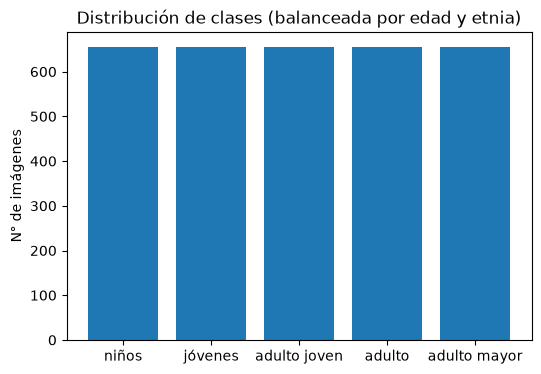

label
niños           656
jóvenes         656
adulto joven    656
adulto          656
adulto mayor    656
Name: count, dtype: int64


In [4]:
# --- Distribución de clases ---
counts = df["label"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Distribución de clases (balanceada por edad y etnia)")
plt.ylabel("N° de imágenes")
plt.show()

print(counts.rename(index=lambda i: CLASS_NAMES[i]))
# Balanceado por muestreo (cap global segmento×etnia) -> barras del mismo alto.

Imágenes por etnia y segmento (deberían ser todas iguales al cap):

race_name     White  Black  Asian  Indian
niños           164    164    164     164
jóvenes         164    164    164     164
adulto joven    164    164    164     164
adulto          164    164    164     164
adulto mayor    164    164    164     164


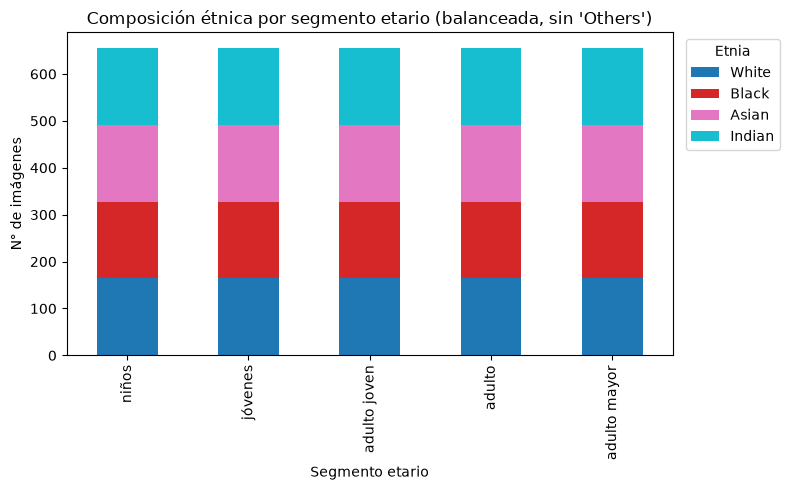

In [5]:
# --- Distribución por ETNIA dentro de cada segmento (debe salir perfectamente pareja) ---
tab = (
    df.assign(race_name=df["race"].map(RACE_NAMES))
      .pivot_table(index="label", columns="race_name", aggfunc="size", fill_value=0)
      .reindex(range(len(CLASS_NAMES)))
)
tab.index = [CLASS_NAMES[i] for i in tab.index]
tab = tab.reindex(columns=list(RACE_NAMES.values()), fill_value=0)

print("Imágenes por etnia y segmento (deberían ser todas iguales al cap):\n")
print(tab.to_string())

ax = tab.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="tab10")
ax.set_title("Composición étnica por segmento etario (balanceada, sin 'Others')")
ax.set_ylabel("N° de imágenes")
ax.set_xlabel("Segmento etario")
ax.legend(title="Etnia", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 2296  |  Val: 492  |  Test: 492


## Parte A: PyTorch


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [8]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [9]:
# --- Entrenamiento (PyTorch) ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
t_inicio_pt = time.time()
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
t_total_pt = time.time() - t_inicio_pt

print(f"\nTiempo total de entrenamiento (PyTorch): {t_total_pt:.2f} segundos")

Epoch 1/10 | train_loss=1.5431 train_acc=0.2927 | val_loss=1.4382 val_acc=0.3720
Epoch 2/10 | train_loss=1.3210 train_acc=0.4377 | val_loss=1.2263 val_acc=0.4959
Epoch 3/10 | train_loss=1.1782 train_acc=0.4952 | val_loss=1.1515 val_acc=0.5407
Epoch 4/10 | train_loss=1.0789 train_acc=0.5440 | val_loss=1.1293 val_acc=0.5407
Epoch 5/10 | train_loss=1.0177 train_acc=0.5871 | val_loss=1.1144 val_acc=0.5386
Epoch 6/10 | train_loss=0.9500 train_acc=0.6106 | val_loss=1.0922 val_acc=0.5610
Epoch 7/10 | train_loss=0.8895 train_acc=0.6359 | val_loss=1.0803 val_acc=0.5711
Epoch 8/10 | train_loss=0.8262 train_acc=0.6603 | val_loss=1.1325 val_acc=0.5488
Epoch 9/10 | train_loss=0.7668 train_acc=0.6794 | val_loss=1.0767 val_acc=0.5772
Epoch 10/10 | train_loss=0.6818 train_acc=0.7247 | val_loss=1.0828 val_acc=0.5671

Tiempo total de entrenamiento (PyTorch): 110.80 segundos


              precision    recall  f1-score   support

       niños       0.83      0.74      0.78        99
     jóvenes       0.52      0.57      0.55        98
adulto joven       0.37      0.45      0.41        98
      adulto       0.47      0.38      0.42        99
adulto mayor       0.61      0.60      0.61        98

    accuracy                           0.55       492
   macro avg       0.56      0.55      0.55       492
weighted avg       0.56      0.55      0.55       492



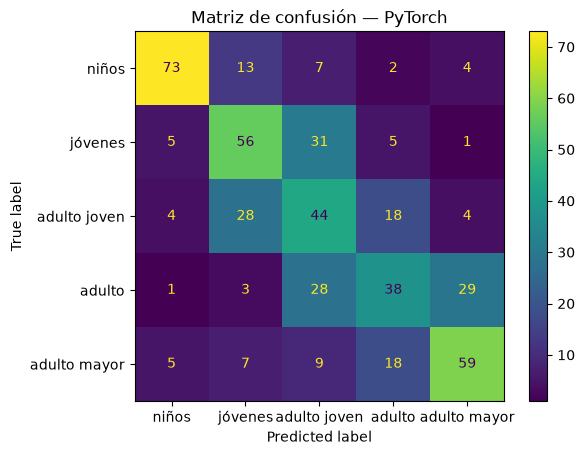

In [10]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — PyTorch")
plt.show()

### Curva ROC — PyTorch

Curva ROC multiclase (One-vs-Rest): cada clase se compara contra el resto. El AUC resume la curva en un número: cercano a **1.0** = excelente separación, **0.5** = equivale al azar. La curva punteada negra es el **micro-promedio** (todas las clases juntas).

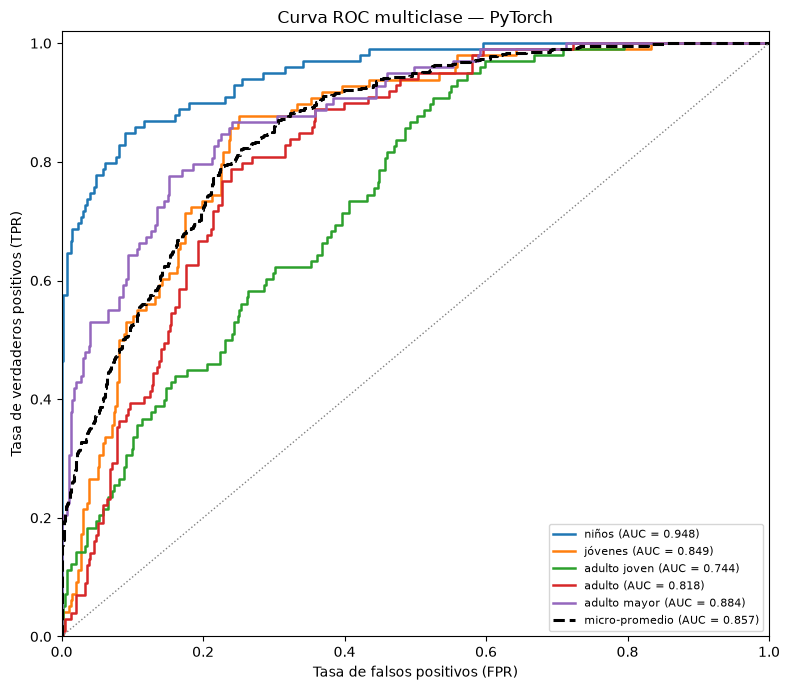

In [11]:
# --- Curva ROC (PyTorch) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Recolectamos las probabilidades (softmax) del modelo sobre el set de test.
model_pt.eval()
probs_pt, y_roc_pt = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        p = F.softmax(model_pt(imgs), dim=1)
        probs_pt.extend(p.cpu().numpy())
        y_roc_pt.extend(labels.numpy())
probs_pt = np.array(probs_pt)
y_roc_pt = np.array(y_roc_pt)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_pt, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_pt[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

# Micro-promedio: junta todas las clases en una sola curva global.
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_pt.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — PyTorch")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Parte B: TensorFlow / Keras


In [12]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [13]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,645 (2.09 MB)

 Trainable params: 548,645 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- Entrenamiento (Keras) ---
EPOCHS_TF = 10
t_inicio_tf = time.time()
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)
t_total_tf = time.time() - t_inicio_tf

print(f"\nTiempo total de entrenamiento (Keras): {t_total_tf:.2f} segundos")

Epoch 1/10


c:\Users\fsali\Documents\GitHub\frameworks-ia-2026_udd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2430 - loss: 1.5979 - val_accuracy: 0.3598 - val_loss: 1.5176
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4033 - loss: 1.3875 - val_accuracy: 0.4228 - val_loss: 1.3173
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4887 - loss: 1.2162 - val_accuracy: 0.4614 - val_loss: 1.2749
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5213 - loss: 1.1350 - val_accuracy: 0.5122 - val_loss: 1.1590
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5597 - loss: 1.0555 - val_accuracy: 0.5346 - val_loss: 1.1051
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5871 - loss: 0.9910 - val_accuracy: 0.5488 - val_loss: 1.1226
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5963 - loss: 0.9514 - val_accuracy: 0.5467 - val_loss: 1.1056
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6337 - loss: 0.8766 - val_accuracy: 0.5691 - val_loss: 1.

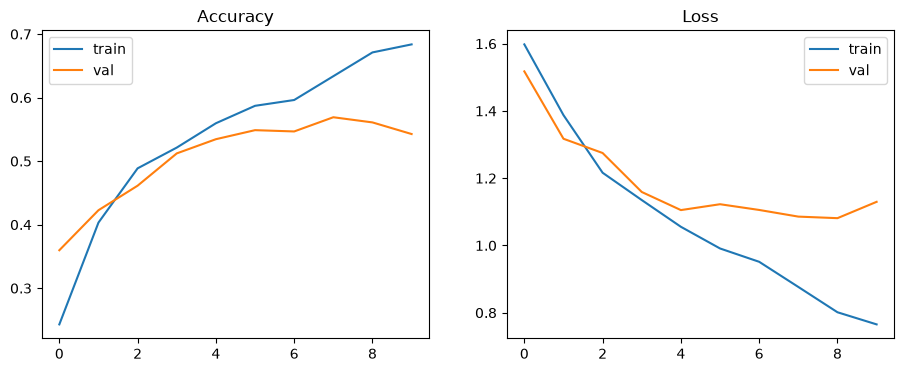

In [15]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

       niños       0.80      0.80      0.80        99
     jóvenes       0.50      0.74      0.60        98
adulto joven       0.40      0.34      0.37        98
      adulto       0.53      0.41      0.46        99
adulto mayor       0.60      0.54      0.57        98

    accuracy                           0.57       492
   macro avg       0.57      0.57      0.56       492
weighted avg       0.57      0.57      0.56       492



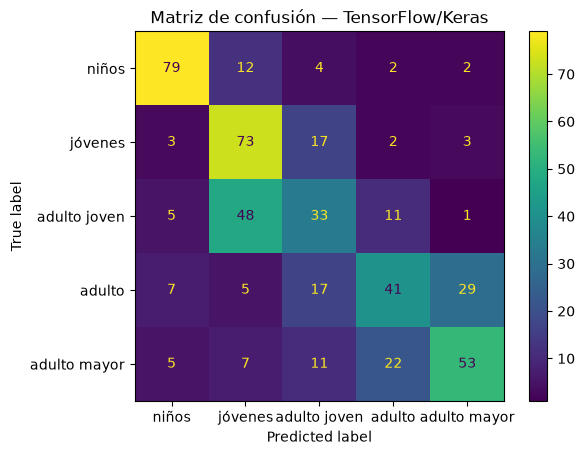

In [16]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — TensorFlow/Keras")
plt.show()

### Curva ROC — TensorFlow/Keras

Misma lectura que la ROC de PyTorch, ahora para el modelo de Keras. Sirve para comparar la capacidad de separación de ambos frameworks clase por clase.

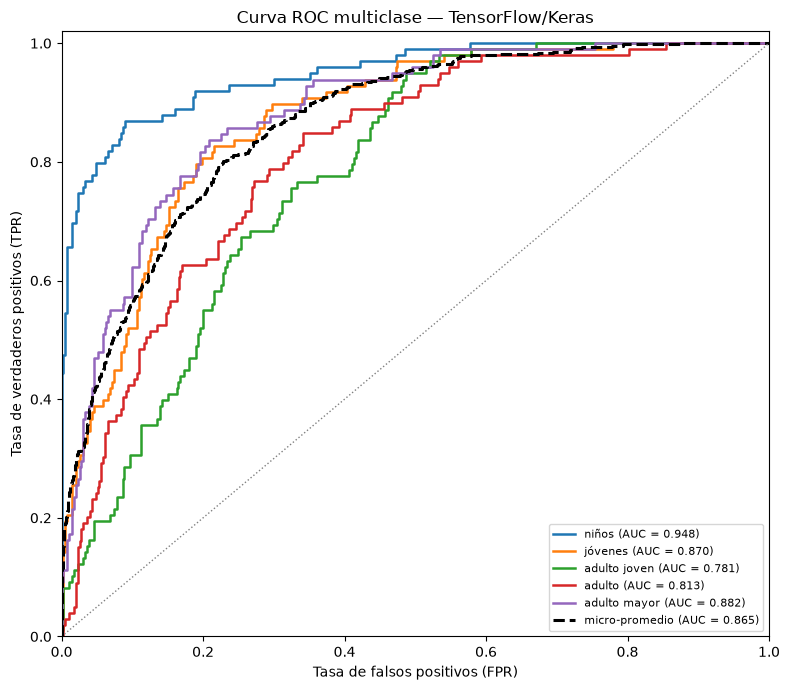

In [17]:
# --- Curva ROC (Keras) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# El modelo de Keras ya entrega softmax en su capa final.
probs_tf, y_roc_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    probs_tf.extend(preds)
    y_roc_tf.extend(labels.numpy())
probs_tf = np.array(probs_tf)
y_roc_tf = np.array(y_roc_tf)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_tf, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_tf[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_tf.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — TensorFlow/Keras")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
# --- Comparación de tiempos de entrenamiento ---
print(f"PyTorch      : {t_total_pt:.2f} s")
print(f"TensorFlow   : {t_total_tf:.2f} s")

PyTorch      : 110.80 s
TensorFlow   : 23.78 s


## Comparación final

En cuanto a los frameworks, los dos quedaron muy parejos en test: PyTorch alcanzó una accuracy de 0.55 y un F1 macro de 0.55, mientras que Keras llegó a una accuracy de 0.57 y un F1 macro de 0.56. Las curvas de loss bajan de forma similar y las curvas ROC quedan claramente por sobre la diagonal en todas las clases, así que, igual que en los análisis anteriores, el framework no es lo que marca la diferencia. La única brecha notoria es el tiempo de entrenamiento: Keras entrenó en unos 24 segundos contra unos 111 segundos de PyTorch, según la celda anterior, diferencia que se explica por cómo cada uno arma el pipeline de datos. Además, como acá balanceamos por edad y también por etnia, las diferencias de desempeño entre clases ya no se pueden atribuir a sesgo étnico, sino que son propias de la dificultad de cada rango de edad.

Volver a 5 segmentos ayudó bastante respecto a las 9 décadas del tercer análisis: al pasar a rangos más anchos, la accuracy subió de alrededor de 0.43 a un rango de 0.55 a 0.57, y el F1 macro de 0.42 a cerca de 0.55. Rangos más anchos significan fronteras menos ambiguas, y con eso el modelo clasifica mejor.

Mirando el F1 por clase, ambos frameworks coinciden en que los extremos son fáciles y el medio es difícil. Los niños quedan con un F1 en torno a 0.78 a 0.80 y el adulto mayor entre 0.57 y 0.61, mientras que las clases centrales, adulto joven y adulto, caen a un F1 de entre 0.37 y 0.46. Esto no es casualidad: los extremos tienen rasgos muy marcados y casi exclusivos de su edad. Un bebé tiene piel lisa, sin manchas ni arrugas, y proporciones faciales distintas; un adulto mayor tiene arrugas profundas, manchas y flacidez muy notorias. Son señales fuertes y difíciles de confundir. En cambio, los segmentos del medio son los más difíciles porque el envejecimiento es un proceso gradual y continuo: los rasgos cambian de a poco y no saltan de un rango al siguiente. Los rasgos de una persona de 28 y una de 34 se solapan casi por completo, de modo que no hay rasgos exclusivos de un rango de edad, sino una transición suave. Por eso el modelo confunde tanto las clases centrales, no porque falle, sino porque la información visual entre rangos vecinos es genuinamente ambigua.

`Para mejorar los resultados en la siguiente entrega intentaremos lo siguiente: más datos, augmentación más agresiva o transfer learning y quizás una red preentrenada en rostros.`


## Prueba 

Test hecho con fotos propias y algunas fotos sacadas del dataset. Estas están en la carpeta fotos_prueba.


Fotos encontradas: 16
Captura de pantalla 2026-07-02 205702.png
PyTorch:
  jóvenes       47.1%
  adulto        24.9%
  adulto joven  18.2%
  niños          6.0%
  adulto mayor   3.7%
Keras:
  jóvenes       26.0%
  adulto        24.8%
  adulto mayor  22.5%
  niños         14.0%
  adulto joven  12.7%
Captura de pantalla 2026-07-02 210925.png
PyTorch:
  adulto mayor  78.0%
  adulto        20.3%
  jóvenes        1.3%
  adulto joven   0.2%
  niños          0.1%
Keras:
  adulto        50.9%
  jóvenes       25.4%
  adulto mayor  14.4%
  adulto joven   7.0%
  niños          2.2%
Captura de pantalla 2026-07-02 210952.png
PyTorch:
  adulto        39.9%
  jóvenes       29.0%
  niños         14.5%
  adulto mayor  13.4%
  adulto joven   3.2%
Keras:
  jóvenes       60.7%
  adulto        25.3%
  niños          6.6%
  adulto joven   6.2%
  adulto mayor   1.2%
Captura de pantalla 2026-07-02 211014.png
PyTorch:
  jóvenes       46.7%
  adulto        20.7%
  niños         16.9%
  adulto joven  13.9%
  adu

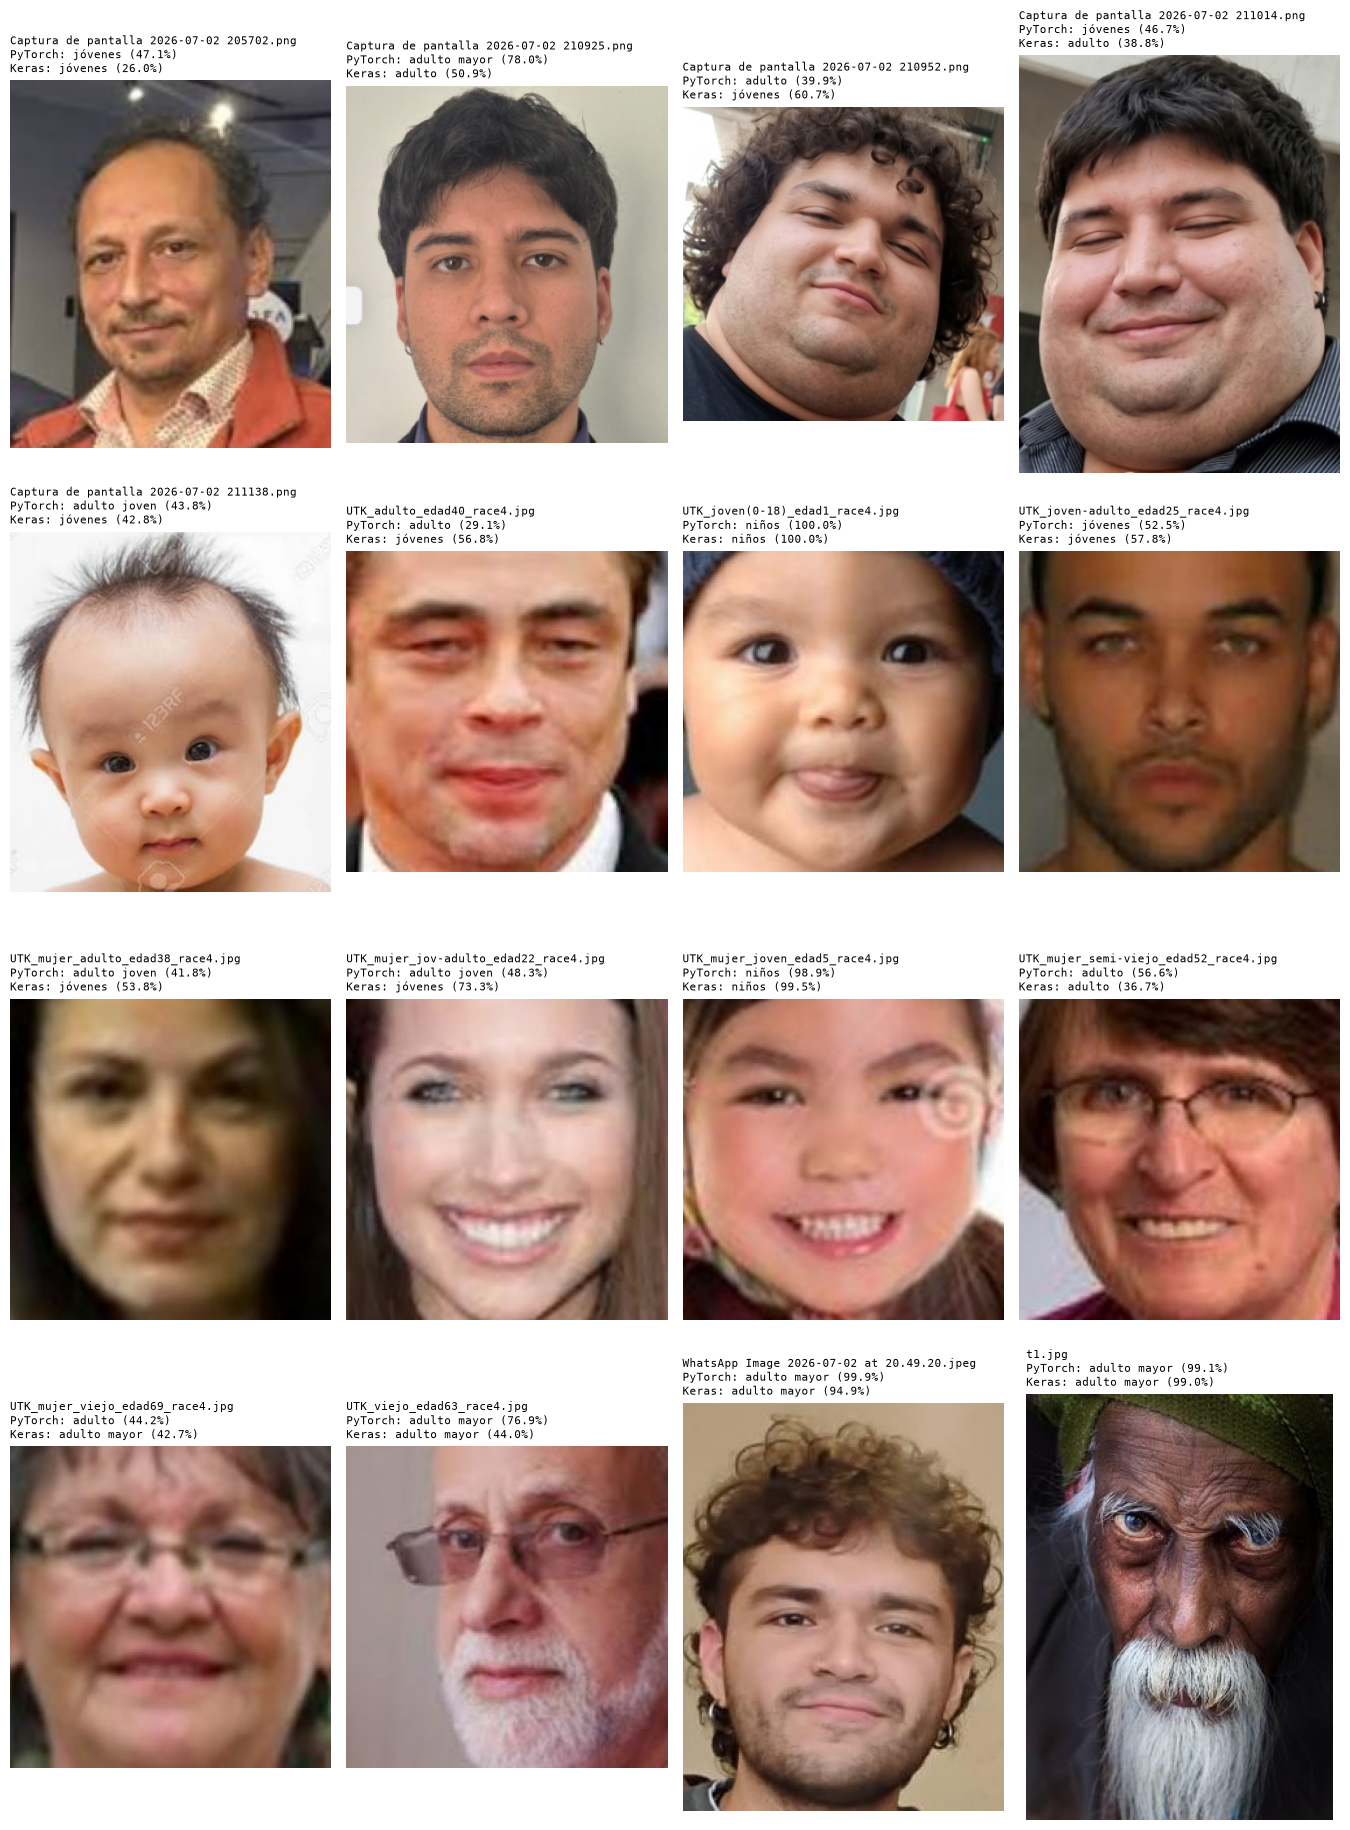

In [19]:
# --- Prueba con imágenes propias ---
# 1) Deja tus fotos (una cara por imagen) en la carpeta FOTOS_PRUEBA.
# 2) Ejecuta esta celda DESPUÉS de haber entrenado los modelos más arriba.
# En consola se imprime el desglose completo de las 5 clases por modelo; sobre cada
# foto de la grilla se muestra solo la categoría elegida por cada método.
import glob
from PIL import Image

FOTOS_PRUEBA = "./fotos_prueba"   # <-- carpeta con tus imágenes de prueba

exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
rutas = []
for e in exts:
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e))
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e.upper()))
rutas = sorted(set(rutas))

if len(rutas) == 0:
    raise FileNotFoundError(
        f"No encontré imágenes en '{FOTOS_PRUEBA}'. Crea la carpeta y deja adentro "
        "algunas fotos (jpg o png), con una cara por imagen."
    )
print(f"Fotos encontradas: {len(rutas)}")

tiene_pt = "model_pt" in globals()   # modelo PyTorch entrenado
tiene_tf = "model_tf" in globals()   # modelo Keras entrenado

def probs_pytorch(img_pil):
    """Devuelve el vector de 5 probabilidades (softmax) del modelo PyTorch."""
    model_pt.eval()
    x = transform(img_pil).unsqueeze(0).to(device)   # mismo preprocesamiento del entrenamiento
    with torch.no_grad():
        return torch.softmax(model_pt(x), dim=1)[0].cpu().numpy()

def probs_keras(img_pil):
    """Devuelve el vector de 5 probabilidades (softmax) del modelo Keras."""
    arr = np.asarray(img_pil.resize((IMG_SIZE, IMG_SIZE)), dtype="float32") / 255.0
    return model_tf.predict(arr[None, ...], verbose=0)[0]

def formatear_todas(probs):
    """Texto con las 5 clases ordenadas de mayor a menor probabilidad (para consola)."""
    orden = np.argsort(probs)[::-1]           # índices de mayor a menor
    return "\n".join(f"  {CLASS_NAMES[i]:<12} {probs[i]*100:5.1f}%" for i in orden)

def formatear_top(probs):
    """Texto con solo la categoría elegida (mayor probabilidad), para el título de la foto."""
    i = int(np.argmax(probs))
    return f"{CLASS_NAMES[i]} ({probs[i]*100:.1f}%)"

# Imprime en consola el desglose completo de cada foto (útil para leer los % con calma)
for ruta in rutas:
    img = Image.open(ruta).convert("RGB")
    print("=" * 40)
    print(os.path.basename(ruta))
    if tiene_pt:
        print("PyTorch:")
        print(formatear_todas(probs_pytorch(img)))
    if tiene_tf:
        print("Keras:")
        print(formatear_todas(probs_keras(img)))
print("=" * 40)

# Muestra las fotos en una grilla; sobre cada foto va solo la clase elegida por cada modelo
n = len(rutas)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.4, rows * 4.6))
axes = np.array(axes).reshape(-1)

for ax, ruta in zip(axes, rutas):
    img = Image.open(ruta).convert("RGB")
    lineas = [os.path.basename(ruta)]
    if tiene_pt:
        lineas.append(f"PyTorch: {formatear_top(probs_pytorch(img))}")
    if tiene_tf:
        lineas.append(f"Keras: {formatear_top(probs_keras(img))}")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("\n".join(lineas), fontsize=8, family="monospace", loc="left")

for ax in axes[n:]:   # apaga los recuadros que sobran en la grilla
    ax.axis("off")

plt.tight_layout()
plt.show()
